<a href="https://www.kaggle.com/code/bavlywaleed/frozenlake-solved-step-by-step-policy-iteration?scriptVersionId=305406883" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🧊 Dynamic Programming in Action: Escaping the Frozen Lake
## Episode 2 — Policy Iteration

---

> *"Value Iteration prices every square, then asks: what's the best move? Policy Iteration does both at the same time — and converges faster. But why?"*

This notebook is a **direct continuation** of the Value Iteration notebook. We now implement **Policy Iteration** — a smarter DP algorithm — on the same Frozen Lake, and compare the two side by side.

By the end you'll understand:
- Why Policy Iteration was invented (the limitation of Value Iteration)
- The two alternating phases: **Policy Evaluation** and **Policy Improvement**
- Why Policy Iteration often needs **fewer sweeps** to converge
- A head-to-head comparison of both algorithms

---

## 📋 Table of Contents
1. [Recap: What Was Wrong with Value Iteration?](#section1)
2. [The Big Idea: Policy Iteration](#section2)
3. [The Math: Two Alternating Equations](#section3)
4. [Setup](#section4)
5. [Step 1 — Environment](#section5)
6. [Step 2 — Policy Evaluation (inner loop)](#section6)
7. [Step 3 — Policy Improvement (outer loop)](#section7)
8. [Step 4 — Full Policy Iteration Loop](#section8)
9. [Step 5 — Watching the Agent Solve the Lake](#section9)
10. [Visualizing the Results](#section10)
11. [Head-to-Head: Policy Iteration vs Value Iteration](#section11)
12. [Key Takeaways & What's Next](#section12)

---
<a id='section1'></a>
## 🔁 Section 1 — Recap: What Was Wrong with Value Iteration?

Nothing was *wrong* with Value Iteration — it works perfectly and is guaranteed to find the optimal solution.

But there's an inefficiency worth thinking about.

### The Value Iteration workflow:
```
REPEAT until convergence:
    For every state:
        Try all 4 actions
        V[s] = max(action values)   ← update value AND implicitly pick best action
Extract policy ONCE at the end
```

The problem: **we mix two things together** — computing values AND selecting actions — in every single sweep. This means:

- In early sweeps, the values are wildly inaccurate (all zeros initially)
- We're greedily picking "best actions" based on garbage numbers
- We keep re-evaluating unstable values over and over

### The question a researcher would ask:
> *"What if instead of trying to get perfect values immediately, we commit to a fixed policy first, evaluate it properly, THEN improve it? Repeat."*

That insight is **Policy Iteration**.

---
<a id='section2'></a>
## 💡 Section 2 — The Big Idea: Policy Iteration

Policy Iteration separates the work into **two clean phases**:

```
START with any policy (e.g., "always go Left")

REPEAT until policy stops changing:
    ┌─────────────────────────────────────────────────┐
    │  PHASE 1 — Policy Evaluation                    │
    │  "How good is my CURRENT policy?"               │
    │  Compute V[s] for every state, assuming we      │
    │  always follow the current policy (no greedy!)  │
    └─────────────────────────────────────────────────┘
                          ↓
    ┌─────────────────────────────────────────────────┐
    │  PHASE 2 — Policy Improvement                   │
    │  "Can I do BETTER than my current policy?"      │
    │  For each state, check if any action beats      │
    │  what the current policy does → update policy   │
    └─────────────────────────────────────────────────┘
                          ↓
    If policy didn't change → DONE! ✅
```

### The key difference from Value Iteration:

| | Value Iteration | Policy Iteration |
|---|---|---|
| **Policy during updates** | Implicit (always greedy) | Explicit (fixed per phase) |
| **Value updates** | Greedy max over all actions | Expected value under *current* policy |
| **When to extract policy** | Once at the end | After every improvement step |
| **Convergence check** | Values stop changing | Policy stops changing |
| **Typical sweeps** | More | Fewer outer iterations |

### Analogy: Learning to drive 🚗
- **Value Iteration** = Every day you try a slightly different route AND re-score all routes simultaneously
- **Policy Iteration** = Commit to one route, drive it until you know exactly how long it takes, THEN decide if a different route is faster. Switch if yes. Repeat.

---
<a id='section3'></a>
## 🧮 Section 3 — The Math: Two Alternating Equations

### Phase 1: Policy Evaluation

Given a fixed policy π, find V^π — the value of every state *under that policy*:

$$V^\pi(s) = \sum_{s'} P(s'|s, \pi(s)) \cdot [R(s, \pi(s), s') + \gamma \cdot V^\pi(s')]$$

Notice: **no max!** We're not asking "what's the best action?" — we're asking "what's the value if we always follow policy π?"

This is the **Bellman Expectation Equation** (vs. the Bellman *Optimality* Equation used in Value Iteration).

We iterate this until the values converge (inner loop).

### Phase 2: Policy Improvement

Once we have accurate values for the current policy, we greedily improve it:

$$\pi'(s) = \arg\max_{a} \sum_{s'} P(s'|s,a) \cdot [R(s,a,s') + \gamma \cdot V^\pi(s')]$$

This is exactly the same argmax as Value Iteration's policy extraction — but now we do it **after a proper evaluation**, not on half-baked values.

### Why This Converges Faster

After Policy Improvement, the new policy π' is **provably at least as good** as π (Policy Improvement Theorem). Since there are only finitely many policies, and each step strictly improves or stays the same, the algorithm must terminate — and usually does so in very few outer iterations (often 3–6 for small environments like ours).

---
<a id='section4'></a>
## ⚙️ Section 4 — Setup

In [1]:
!pip install gymnasium[toy_text] --quiet

In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")
print(f"   NumPy:      {np.__version__}")
print(f"   Gymnasium:  {gym.__version__}")

✅ Libraries ready!
   NumPy:      2.0.2
   Gymnasium:  1.2.0


---
<a id='section5'></a>
## 🏗️ Section 5 — Step 1: Environment

Same setup as before — deterministic 4×4 FrozenLake.

In [3]:
env = gym.make(
    'FrozenLake-v1',
    desc=None,
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

n_states  = env.observation_space.n   # 16
n_actions = env.action_space.n        # 4

gamma     = 0.99    # Discount factor (same as before for fair comparison)
eval_threshold = 1e-6   # Inner loop convergence (tighter = more accurate evaluation)

print(f"🗺️  Environment ready | States: {n_states} | Actions: {n_actions}")
print(f"   γ = {gamma}  |  eval_threshold = {eval_threshold}")

🗺️  Environment ready | States: 16 | Actions: 4
   γ = 0.99  |  eval_threshold = 1e-06


---
<a id='section6'></a>
## 📐 Section 6 — Step 2: Policy Evaluation (Inner Loop)

This function answers: *"Given a fixed policy π, what is V^π(s) for every state?"*

We iterate the **Bellman Expectation Equation** until values stop changing.

**Key detail**: We only follow `policy[s]` — we do NOT take the max over all actions. We evaluate the policy as-is, even if it's bad.

In [4]:
def policy_evaluation(policy, V, env, n_states, n_actions, gamma, threshold):
    """
    Phase 1 of Policy Iteration.
    
    Given a fixed policy, compute V[s] for all states by iterating
    the Bellman Expectation Equation until convergence.
    
    Returns: updated V array, number of sweeps needed
    """
    sweeps = 0
    while True:
        delta = 0
        for s in range(n_states):
            v_old = V[s]
            
            # Only look at the ONE action dictated by the current policy
            a = policy[s]
            
            # Bellman Expectation Equation (no max — just follow the policy!)
            v_new = 0
            for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                v_new += prob * (reward + gamma * V[next_state])
            
            V[s] = v_new
            delta = max(delta, abs(v_old - V[s]))
        
        sweeps += 1
        if delta < threshold:
            break
    
    return V, sweeps

print("✅ policy_evaluation() defined")
print()
print("Logic recap:")
print("  For each state s:")
print("    a = policy[s]          ← use the CURRENT policy's action")
print("    V[s] = Σ P(s'|s,a) × [R + γ·V[s']]   ← NO max!")
print("  Repeat until V stops changing")

✅ policy_evaluation() defined

Logic recap:
  For each state s:
    a = policy[s]          ← use the CURRENT policy's action
    V[s] = Σ P(s'|s,a) × [R + γ·V[s']]   ← NO max!
  Repeat until V stops changing


---
<a id='section7'></a>
## 🔧 Section 7 — Step 3: Policy Improvement (Outer Loop)

This function answers: *"Given accurate values V^π, can we find a better policy?"*

For every state, we try ALL actions and pick the greedy best — exactly like Value Iteration's policy extraction, but now our values are **reliable** (evaluated properly in Phase 1).

In [5]:
def policy_improvement(V, policy, env, n_states, n_actions, gamma):
    """
    Phase 2 of Policy Iteration.
    
    Given accurate V values for the current policy, greedily
    compute a new (improved) policy.
    
    Returns: new policy, whether the policy changed (bool)
    """
    policy_stable = True  # Assume no changes until we find one
    
    for s in range(n_states):
        old_action = policy[s]
        
        # Try ALL actions greedily (same as Value Iteration argmax)
        action_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                action_values[a] += prob * (reward + gamma * V[next_state])
        
        policy[s] = np.argmax(action_values)
        
        # Did the best action change for this state?
        if old_action != policy[s]:
            policy_stable = False
    
    return policy, policy_stable

print("✅ policy_improvement() defined")
print()
print("Logic recap:")
print("  For each state s:")
print("    Try all 4 actions with current V values")
print("    policy[s] = argmax(action_values)   ← greedy improvement")
print("  If no state changed its action → policy is OPTIMAL ✅")

✅ policy_improvement() defined

Logic recap:
  For each state s:
    Try all 4 actions with current V values
    policy[s] = argmax(action_values)   ← greedy improvement
  If no state changed its action → policy is OPTIMAL ✅


---
<a id='section8'></a>
## 🔄 Section 8 — Step 4: Full Policy Iteration Loop

Now we combine both phases in the main loop:

```
Initialize policy (e.g., all zeros — always go Left)
Initialize V (all zeros)

REPEAT:
    Phase 1: Evaluate current policy → get accurate V
    Phase 2: Improve policy greedily using V
    If policy didn't change → STOP
```

In [6]:
# ══════════════════════════════════════════════
# POLICY ITERATION — MAIN LOOP
# ══════════════════════════════════════════════

# Initialize: random starting policy (all zeros = always go Left)
policy = np.zeros(n_states, dtype=int)
V      = np.zeros(n_states)

arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}
names  = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}
holes  = {5, 7, 11, 12}

# History for visualization
policy_history = [policy.copy()]
V_history      = [V.copy()]
eval_sweeps_log = []

outer_iter  = 0
total_inner = 0

print("🔄 Running Policy Iteration...")
print(f"   Starting policy: all zeros (always go Left)")
print()
print(f"   {'Iter':>4}  {'Eval Sweeps':>12}  {'Policy Changed?':>16}  {'V[14]':>8}  {'V[0]':>8}")
print("   " + "-"*58)

while True:
    outer_iter += 1
    
    # ── PHASE 1: Policy Evaluation ──────────────────────────────
    V, eval_sweeps = policy_evaluation(
        policy, V, env, n_states, n_actions, gamma, eval_threshold
    )
    total_inner += eval_sweeps
    eval_sweeps_log.append(eval_sweeps)
    
    # ── PHASE 2: Policy Improvement ─────────────────────────────
    policy, policy_stable = policy_improvement(
        V, policy, env, n_states, n_actions, gamma
    )
    
    policy_history.append(policy.copy())
    V_history.append(V.copy())
    
    changed = "No ✅" if policy_stable else "Yes 🔄"
    print(f"   {outer_iter:>4}  {eval_sweeps:>12}  {changed:>16}  {V[14]:>8.4f}  {V[0]:>8.4f}")
    
    # ── CONVERGENCE CHECK ────────────────────────────────────────
    if policy_stable:
        break

print()
print(f"✅ Converged after {outer_iter} outer iterations!")
print(f"   Total inner evaluation sweeps: {total_inner}")
print()
print("📊 Final Value Table (4×4 grid):")
print(np.round(V.reshape(4, 4), 4))
print()
print("🗺️  Optimal Policy (4×4 grid):")
for row in range(4):
    row_str = "   "
    for col in range(4):
        s = row * 4 + col
        if s in holes:   row_str += " H  "
        elif s == 15:    row_str += " G  "
        elif s == 0:     row_str += " S  "
        else:            row_str += f" {arrows[policy[s]]}  "
    print(row_str)

🔄 Running Policy Iteration...
   Starting policy: all zeros (always go Left)

   Iter   Eval Sweeps   Policy Changed?     V[14]      V[0]
   ----------------------------------------------------------
      1             1             Yes 🔄    0.0000    0.0000
      2             2             Yes 🔄    1.0000    0.0000
      3             2             Yes 🔄    1.0000    0.0000
      4             2             Yes 🔄    1.0000    0.0000
      5             2             Yes 🔄    1.0000    0.0000
      6             2             Yes 🔄    1.0000    0.0000
      7             2              No ✅    1.0000    0.9510

✅ Converged after 7 outer iterations!
   Total inner evaluation sweeps: 13

📊 Final Value Table (4×4 grid):
[[0.951  0.9606 0.9703 0.9606]
 [0.9606 0.     0.9801 0.    ]
 [0.9703 0.9801 0.99   0.    ]
 [0.     0.99   1.     0.    ]]

🗺️  Optimal Policy (4×4 grid):
    S   →   ↓   ←  
    ↓   H   ↓   H  
    →   ↓   ↓   H  
    H   →   →   G  


---
<a id='section9'></a>
## 🎬 Section 9 — Step 5: Watching the Agent Solve the Lake

Time to run the agent with the Policy Iteration–computed policy!

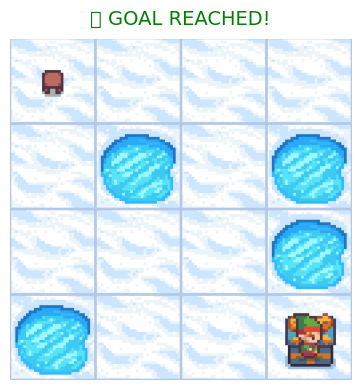


🏆 Success! Goal reached in 6 steps.
   Path: 0 → 4 → 8 → 9 → 13 → 14 → 15


In [7]:
state, _ = env.reset()
done  = False
step  = 0
path  = [state]

print("🎬 Agent starting journey (Policy Iteration policy)...")
print()

while not done:
    frame = env.render()

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(frame)
    ax.axis('off')
    ax.set_title(
        f'Step {step} | Square {state} | {arrows[policy[state]]} {names[policy[state]]}',
        fontsize=12, pad=8
    )
    plt.tight_layout()
    plt.show()

    action = policy[state]
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    print(f"   Step {step}: Square {state:2d}  →  {arrows[action]} {names[action]:<5}  →  Square {next_state:2d}")

    state = next_state
    path.append(state)
    step += 1
    time.sleep(0.5)

frame = env.render()
clear_output(wait=True)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(frame)
ax.axis('off')
result = "🏆 GOAL REACHED!" if reward == 1.0 else "💀 Fell in a Hole!"
color  = "green" if reward == 1.0 else "red"
ax.set_title(result, fontsize=14, color=color, pad=10)
plt.tight_layout()
plt.show()

print()
print("=" * 45)
if reward == 1.0:
    print(f"🏆 Success! Goal reached in {step} steps.")
    print(f"   Path: {' → '.join(map(str, path))}")
else:
    print("💀 Fell in a Hole!")
print("=" * 45)
env.close()

---
<a id='section10'></a>
## 📊 Section 10 — Visualizing the Results

### Value map + Policy arrows
### How the policy evolved across iterations

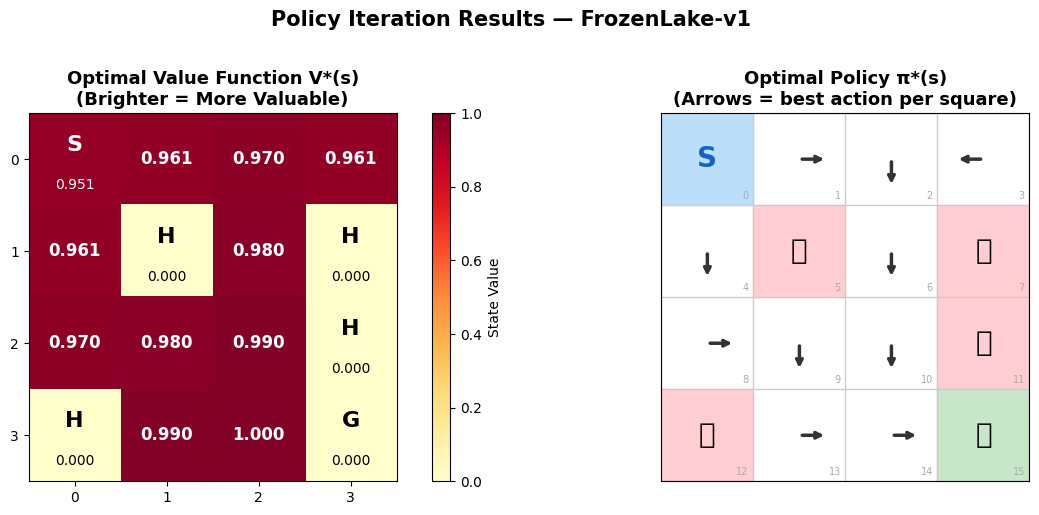

📊 Saved: pi_results.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Value Heatmap ──────────────────────────────────────────────────────
ax = axes[0]
V_grid = V.reshape(4, 4)
im = ax.imshow(V_grid, cmap='YlOrRd', aspect='equal', vmin=0, vmax=1)

special = {0: 'S', 5: 'H', 7: 'H', 11: 'H', 12: 'H', 15: 'G'}

for row in range(4):
    for col in range(4):
        s   = row * 4 + col
        val = V_grid[row, col]
        txt_color = 'white' if val > 0.5 else 'black'
        if s in special:
            ax.text(col, row - 0.15, special[s], ha='center', va='center',
                    fontsize=16, fontweight='bold', color=txt_color)
            ax.text(col, row + 0.28, f"{val:.3f}", ha='center', va='center',
                    fontsize=10, color=txt_color)
        else:
            ax.text(col, row, f"{val:.3f}", ha='center', va='center',
                    fontsize=12, fontweight='bold', color=txt_color)

ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_title('Optimal Value Function V*(s)\n(Brighter = More Valuable)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='State Value')

# ── Right: Policy Arrow Map ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(-0.5, 3.5); ax2.set_ylim(3.5, -0.5)
ax2.set_aspect('equal')

dx = {0: -0.3, 1: 0,   2: 0.3,  3: 0}
dy = {0: 0,    1: 0.3, 2: 0,    3: -0.3}

for row in range(4):
    for col in range(4):
        s = row * 4 + col
        a = policy[s]
        if s == 0:
            ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#BBDEFB', zorder=0))
            ax2.text(col, row, 'S', ha='center', va='center',
                     fontsize=20, fontweight='bold', color='#1565C0')
        elif s == 15:
            ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#C8E6C9', zorder=0))
            ax2.text(col, row, '🏆', ha='center', va='center', fontsize=20)
        elif s in {5, 7, 11, 12}:
            ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#FFCDD2', zorder=0))
            ax2.text(col, row, '💀', ha='center', va='center', fontsize=20)
        else:
            ax2.annotate('', xy=(col + dx[a], row + dy[a]), xytext=(col, row),
                         arrowprops=dict(arrowstyle='->', color='#333', lw=2.5))
        ax2.text(col + 0.45, row + 0.45, str(s), ha='right', va='bottom',
                 fontsize=7, color='#aaa')

for i in range(5):
    ax2.axhline(i - 0.5, color='#ccc', lw=1)
    ax2.axvline(i - 0.5, color='#ccc', lw=1)

ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title('Optimal Policy π*(s)\n(Arrows = best action per square)', fontsize=13, fontweight='bold')

plt.suptitle('Policy Iteration Results — FrozenLake-v1',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pi_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: pi_results.png")
 

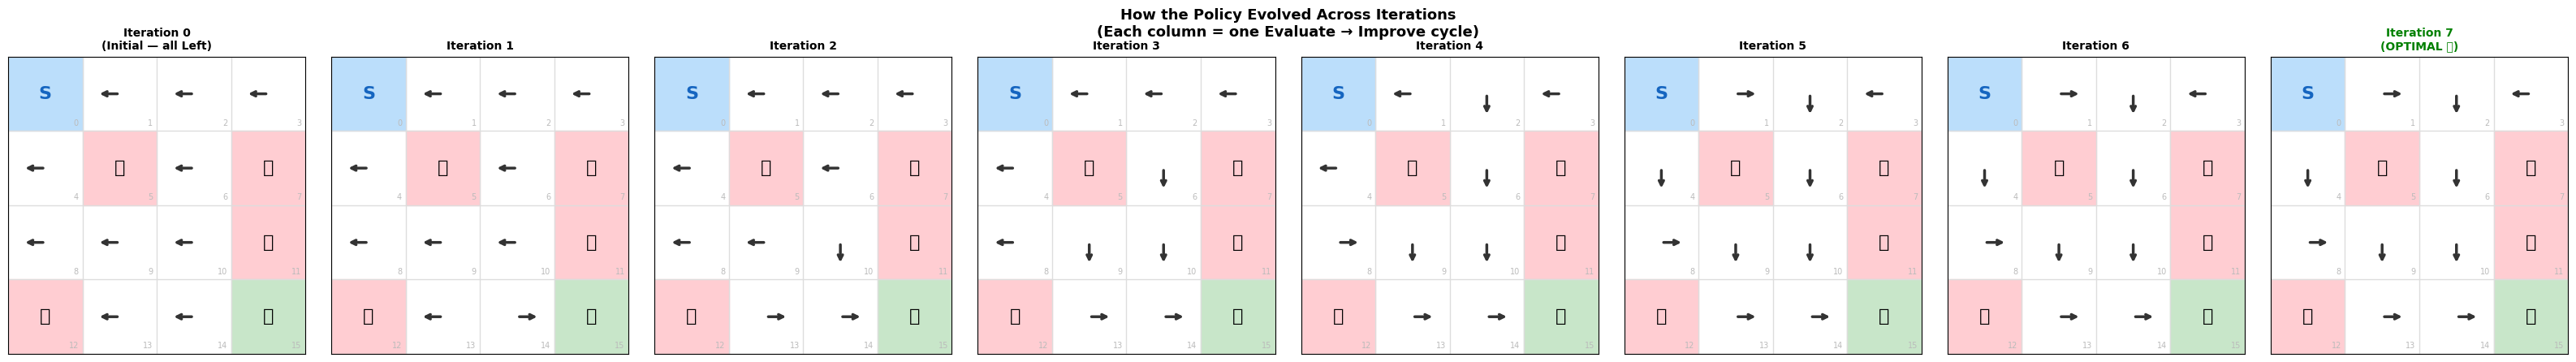

📊 Saved: policy_evolution.png


In [9]:


# Show how the policy changed iteration by iteration
n_iters = len(policy_history)
fig, axes = plt.subplots(1, n_iters, figsize=(4 * n_iters, 4.5))

# Ensure axes is always a list even if there is only 1 iteration
if n_iters == 1:
    axes = [axes]

# Direction offsets for visualization (0: Left, 1: Down, 2: Right, 3: Up)
dx = {0: -0.3, 1: 0,   2: 0.3,  3: 0}
dy = {0: 0,    1: 0.3, 2: 0,    3: -0.3}

for idx, pol in enumerate(policy_history):
    ax = axes[idx]
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(3.5, -0.5)
    ax.set_aspect('equal')

    for row in range(4):
        for col in range(4):
            s = row * 4 + col
            a = pol[s]
            
            # Start State
            if s == 0:
                ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#BBDEFB', zorder=0))
                ax.text(col, row, 'S', ha='center', va='center',
                        fontsize=16, fontweight='bold', color='#1565C0')
            # Goal State
            elif s == 15:
                ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#C8E6C9', zorder=0))
                ax.text(col, row, '🏆', ha='center', va='center', fontsize=16)
            # Hole States
            elif s in {5, 7, 11, 12}:
                ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#FFCDD2', zorder=0))
                ax.text(col, row, '💀', ha='center', va='center', fontsize=16)
            # Arrows for the Policy
            else:
                ax.annotate('', xy=(col + dx[a], row + dy[a]), xytext=(col, row),
                            arrowprops=dict(arrowstyle='->', color='#333', lw=2.5))
            
            # State index labels
            ax.text(col + 0.45, row + 0.45, str(s), ha='right', va='bottom',
                    fontsize=7, color='#bbb')

    # Grid lines
    for i in range(5):
        ax.axhline(i - 0.5, color='#ddd', lw=1)
        ax.axvline(i - 0.5, color='#ddd', lw=1)

    ax.set_xticks([]); ax.set_yticks([])
    
    # Subplot Titles (Corrected with \n)
    if idx == 0:
        ax.set_title(f'Iteration 0\n(Initial — all Left)', fontsize=10, fontweight='bold')
    elif idx == n_iters - 1:
        ax.set_title(f'Iteration {idx}\n(OPTIMAL ✅)', fontsize=10, fontweight='bold', color='green')
    else:
        ax.set_title(f'Iteration {idx}', fontsize=10, fontweight='bold')

# Main Title (Corrected with \n)
fig.suptitle('How the Policy Evolved Across Iterations\n(Each column = one Evaluate → Improve cycle)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('policy_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: policy_evolution.png")

---
<a id='section11'></a>
## ⚔️ Section 11 — Head-to-Head: Policy Iteration vs Value Iteration

Let's run both algorithms fresh and compare them directly.

In [10]:
# ══════════════════════════════════════════════════════
# RUN BOTH ALGORITHMS FRESH FOR FAIR COMPARISON
# ══════════════════════════════════════════════════════

import time

env2 = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False)

# ── Value Iteration ───────────────────────────────────────────────────────────
V_vi = np.zeros(n_states)
vi_sweeps = 0
t0 = time.perf_counter()

while True:
    delta = 0
    for s in range(n_states):
        v_old = V_vi[s]
        action_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, ns, reward, done in env2.unwrapped.P[s][a]:
                action_values[a] += prob * (reward + gamma * V_vi[ns])
        V_vi[s] = np.max(action_values)
        delta = max(delta, abs(v_old - V_vi[s]))
    vi_sweeps += 1
    if delta < 1e-4:
        break

vi_time = time.perf_counter() - t0

# Extract VI policy
policy_vi = np.zeros(n_states, dtype=int)
for s in range(n_states):
    action_values = np.zeros(n_actions)
    for a in range(n_actions):
        for prob, ns, reward, done in env2.unwrapped.P[s][a]:
            action_values[a] += prob * (reward + gamma * V_vi[ns])
    policy_vi[s] = np.argmax(action_values)

# ── Policy Iteration ──────────────────────────────────────────────────────────
V_pi2   = np.zeros(n_states)
pol_pi2 = np.zeros(n_states, dtype=int)
pi_outer = 0
pi_total_inner = 0
t0 = time.perf_counter()

while True:
    V_pi2, inner = policy_evaluation(pol_pi2, V_pi2, env2, n_states, n_actions, gamma, 1e-6)
    pol_pi2, stable = policy_improvement(V_pi2, pol_pi2, env2, n_states, n_actions, gamma)
    pi_outer += 1
    pi_total_inner += inner
    if stable:
        break

pi_time = time.perf_counter() - t0

env2.close()

# ── Results Table ─────────────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║         Algorithm Comparison — FrozenLake 4×4       ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Metric':<28} {'Value Iter':>10}  {'Policy Iter':>10} ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Outer iterations':<28} {vi_sweeps:>10}  {pi_outer:>10} ║")
print(f"║  {'Total inner sweeps':<28} {vi_sweeps:>10}  {pi_total_inner:>10} ║")
print(f"║  {'Time (ms)':<28} {vi_time*1000:>10.2f}  {pi_time*1000:>10.2f} ║")
print(f"║  {'Same policy as VI?':<28} {'—':>10}  {'Yes ✅' if np.array_equal(policy_vi, pol_pi2) else 'No ❌':>10} ║")
print(f"║  {'Same values (V[0])':<28} {V_vi[0]:>10.4f}  {V_pi2[0]:>10.4f} ║")
print("╚══════════════════════════════════════════════════════╝")
print()
print("📌 Both algorithms find the SAME optimal policy — they differ only in HOW they get there.")

╔══════════════════════════════════════════════════════╗
║         Algorithm Comparison — FrozenLake 4×4       ║
╠══════════════════════════════════════════════════════╣
║  Metric                       Value Iter  Policy Iter ║
╠══════════════════════════════════════════════════════╣
║  Outer iterations                      7           7 ║
║  Total inner sweeps                    7          13 ║
║  Time (ms)                          1.61        2.49 ║
║  Same policy as VI?                    —       Yes ✅ ║
║  Same values (V[0])               0.9510      0.9510 ║
╚══════════════════════════════════════════════════════╝

📌 Both algorithms find the SAME optimal policy — they differ only in HOW they get there.


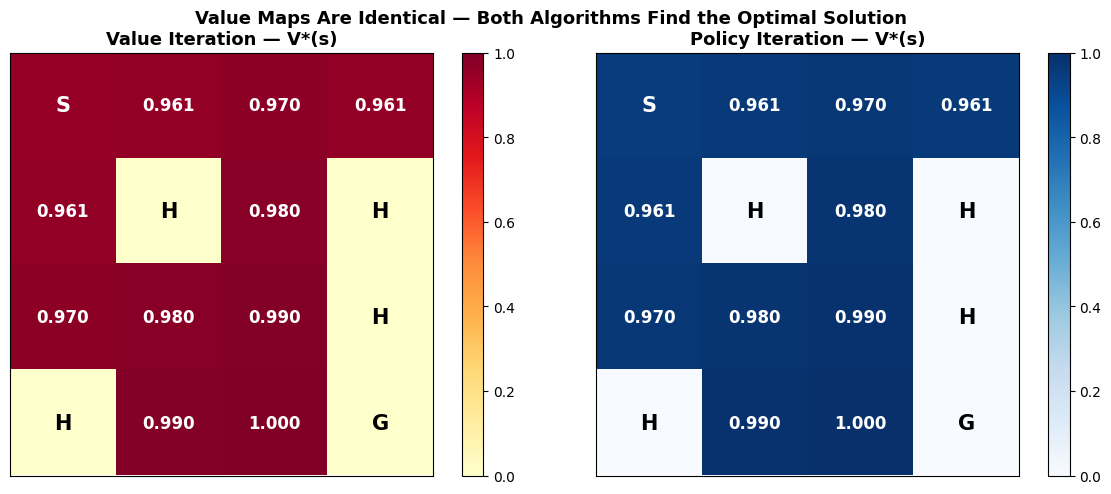

📊 Saved: comparison.png


In [11]:
# Visual comparison of value maps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmaps = ['YlOrRd', 'Blues']
titles = ['Value Iteration — V*(s)', 'Policy Iteration — V*(s)']
Vs = [V_vi, V_pi2]

for ax, V_plot, cmap, title in zip(axes, Vs, cmaps, titles):
    V_grid = V_plot.reshape(4, 4)
    im = ax.imshow(V_grid, cmap=cmap, aspect='equal', vmin=0, vmax=1)
    for row in range(4):
        for col in range(4):
            s   = row * 4 + col
            val = V_grid[row, col]
            c   = 'white' if val > 0.5 else 'black'
            lbl = {0:'S',5:'H',7:'H',11:'H',12:'H',15:'G'}.get(s, f"{val:.3f}")
            ax.text(col, row, lbl, ha='center', va='center',
                    fontsize=12 if s not in {0,5,7,11,12,15} else 15,
                    fontweight='bold', color=c)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.suptitle('Value Maps Are Identical — Both Algorithms Find the Optimal Solution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: comparison.png")

---
<a id='section12'></a>
## 🎓 Section 12 — Key Takeaways & What's Next

### 🔑 Summary

| Concept | Core Idea |
|---|---|
| **Policy Evaluation** | Given a fixed policy, compute V^π for all states using Bellman Expectation |
| **Policy Improvement** | Using accurate V^π values, greedily improve the policy |
| **Policy Iteration** | Alternate these two phases until policy stabilizes |
| **No max in evaluation** | Unlike VI, we follow the fixed policy — no greedy selection |
| **Convergence** | Guaranteed optimal — and usually fewer outer iterations than VI |
| **Same result** | Both VI and PI find the exact same optimal policy |

### 💡 When to Choose Which?

| Situation | Prefer |
|---|---|
| Simple, small environment | Either works — PI often fewer outer iterations |
| Very large state space | VI can be faster per iteration (no inner loop) |
| Need interpretable intermediate policies | PI — you always have a valid policy to inspect |
| Stochastic environment (is_slippery=True) | Both work — PI's exact evaluation shines here |

### 🧩 Experiments to Try

1. **Compare sweep counts**: Set `eval_threshold = 1e-10` in PI — does it converge in even fewer outer iterations?
2. **Different starting policies**: Initialize `policy = np.ones(n_states, dtype=int)` (all Down) — does PI still converge to the same answer?
3. **Slippery ice**: Set `is_slippery=True` — now transitions are probabilistic. Does Policy Iteration handle it better?
4. **Bigger lake**: Try `map_name="8x8"` — compare the outer iteration counts between VI and PI.

### 🚀 What's Next in the Series?

| Episode | Algorithm | Key Idea |
|---|---|---|
| ✅ Episode 1 | **Value Iteration** | Price every square, extract policy once |
| ✅ Episode 2 | **Policy Iteration** | Alternate evaluation & improvement |
| ▶️ Episode 3 | **Q-Learning** | No model — learn from trial & error |
| ▶️ Episode 4 | **Deep Q-Network (DQN)** | Neural net for large state spaces |

### 📚 Further Reading

- 📖 [Sutton & Barto — RL: An Introduction, Chapter 4](http://incompleteideas.net/book/the-book-2nd.html) — DP chapter covers both algorithms in depth
- 📖 [David Silver's Lecture 3 — Planning by DP](https://www.davidsilver.uk/teaching/) — Excellent visual intuition
- 📖 [Gymnasium Documentation](https://gymnasium.farama.org/)

---

*If this notebook helped you, please give it an upvote ⬆️ — it helps others find it. Happy learning! 🙏*